In [267]:
import uproot
import awkward
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [431]:
halfLenX = 180
halfLenY = 300
halfLenZ = 180
nRows = 40
nCols = 24

In [432]:
with open('build/positions_24_40.txt') as f:
    OpDetPositions = [(x) for x in [i.replace('\n','').split(" ") for i in f.readlines()]]
    
for num in range(0, len(OpDetPositions)):
    OpDetPositions[num]= [float(i) for i in OpDetPositions[num]]
    
input_file = uproot.open("build/Output.root" )   
SimPhotonsTree=input_file['event;8']
SimPhotonsBranch=SimPhotonsTree.arrays()
SavedPhotons=SimPhotonsBranch['SavedPhotons']  
PhotonsPerOpDet=[]
for num in range(0, len(SavedPhotons[0])):
    PhotonsPerOpDet.append(np.array(SavedPhotons[0,num]))

In [438]:
number_of_detectors=len(OpDetPositions)
max_time=7000 #Max time to analyze
time_map=np.zeros((max_time,number_of_detectors))
for detector in range(0,number_of_detectors):
    for num in range(0, len(PhotonsPerOpDet[detector])):
        time_map[int(PhotonsPerOpDet[detector][num]),detector]+=1
h=[]
for num in range(0,len(time_map)):
    h.append(np.reshape(time_map[num],(-1,nCols)))
maxNPhotons=max([np.amax(i) for i in h])

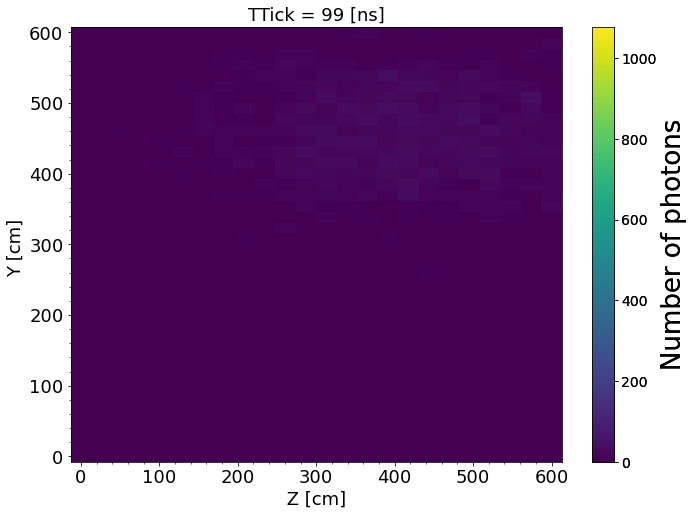

In [437]:
y_bins=np.linspace(0,2*halfLenY,nRows)
z_bins=np.linspace(0,2*halfLenY,nCols)

fig, ax = plt.subplots(1, figsize=(11,8))
def animate(i):
    pcm=ax.pcolormesh(z_bins,y_bins, h[i],vmin=0, vmax=maxNPhotons)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.minorticks_on()
    ax.set_ylabel(r'Y [cm] ', fontsize=18)
    ax.set_xlabel(r' Z [cm] ', fontsize=18)
    ax.set_title('TTick = ' + str(i) + ' [ns]',fontsize=18)
    #ax.legend(fontsize=18, loc=1)
    if i==0:
        cb=fig.colorbar(pcm)
        cb.remove()
        cb=fig.colorbar(pcm)
        cb.set_label(r'Number of photons', fontsize=26)
        cb.ax.tick_params(labelsize=14)
    #ax.set_title(r"Angle  $\theta$ $\in$ [70-80] deg", fontsize=22, pad=30)
    return fig

ani = FuncAnimation(fig, animate, 100 , interval=150)
HTML(ani.to_jshtml())
